In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

file_path = "dataset.csv"

df = pd.read_csv(file_path, nrows=40000, low_memory=False)

print("Loaded rows:", len(df))
print("\nShape:", df.shape)
print("\nTop Columns:")
print(df.columns[:10])

Loaded rows: 40000

Shape: (40000, 151)

Top Columns:
Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade'],
      dtype='object')



Top Missing Columns:
sec_app_open_acc            100.0
member_id                   100.0
revol_bal_joint             100.0
sec_app_fico_range_low      100.0
sec_app_fico_range_high     100.0
sec_app_earliest_cr_line    100.0
sec_app_inq_last_6mths      100.0
sec_app_mort_acc            100.0
sec_app_revol_util          100.0
sec_app_open_act_il         100.0
dtype: float64


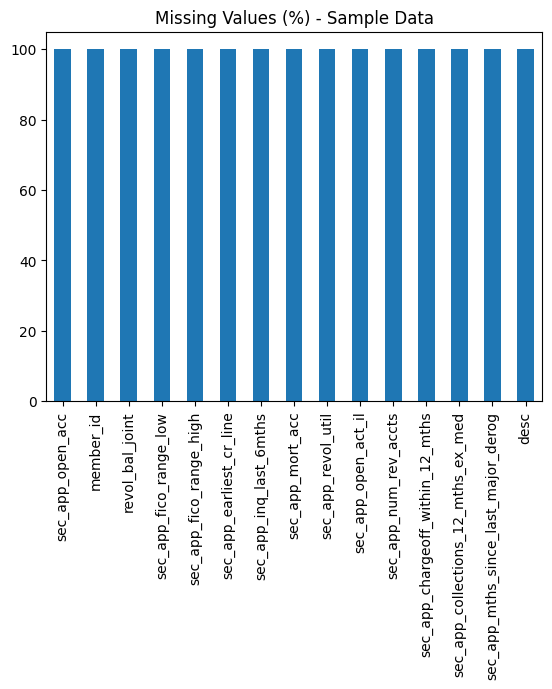


Loan Status Distribution:
loan_status
Fully Paid            27969
Charged Off            7226
Current                4476
Late (31-120 days)      209
In Grace Period          87
Late (16-30 days)        32
Default                   1
Name: count, dtype: int64


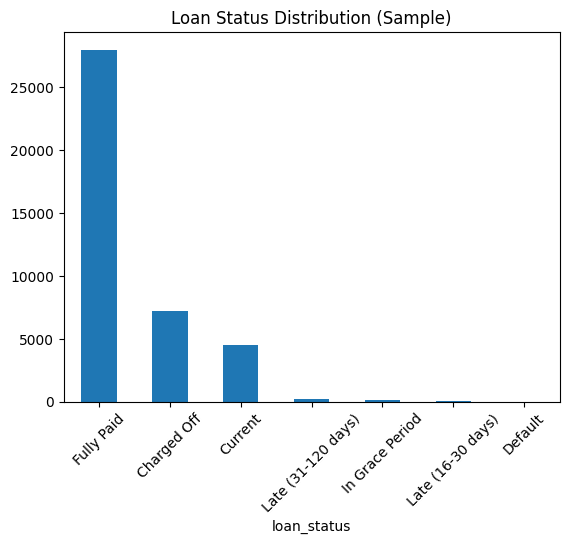

In [3]:
# STEP - Dealing with missing values
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)

print("\nTop Missing Columns:")
print(missing_percent.head(10))

plt.figure()
missing_percent.head(15).plot(kind='bar')
plt.title("Missing Values (%) - Sample Data")
plt.xticks(rotation=90)
plt.show()

print("\nLoan Status Distribution:")
print(df['loan_status'].value_counts())

df['loan_status'].value_counts().plot(kind='bar')
plt.title("Loan Status Distribution (Sample)")
plt.xticks(rotation=45)
plt.show()

In [4]:

# STEP - SELECTIVE CLEANING

print("\nOriginal Loan Status:\n", df['loan_status'].value_counts())
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df['target'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

# Dropping columns with 100% misssing data

missing_percent = df.isnull().mean() * 100
full_missing_cols = missing_percent[missing_percent == 100].index
print("\n100% Missing Columns:\n", list(full_missing_cols))
df.drop(columns=full_missing_cols, inplace=True)

print("\nShape after removing 100% missing columns:", df.shape)


# Creating missing flags

missing_percent = df.isnull().mean() * 100
high_missing_cols = missing_percent[missing_percent > 30].index
for col in high_missing_cols:
    df[col + "_missing_flag"] = df[col].isnull().astype(int)

# Imputation

num_cols = df.select_dtypes(include=['float32', 'float64', 'int32', 'int64']).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
missing_after = df.isnull().mean() * 100


Original Loan Status:
 loan_status
Fully Paid            27969
Charged Off            7226
Current                4476
Late (31-120 days)      209
In Grace Period          87
Late (16-30 days)        32
Default                   1
Name: count, dtype: int64

100% Missing Columns:
 ['member_id', 'next_pymnt_d', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog']

Shape after removing 100% missing columns: (35195, 137)


C:\Users\shrut\AppData\Local\Temp\ipykernel_7932\1766377449.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\shrut\AppData\Local\Temp\ipykernel_7932\1766377449.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
C:\Users\shrut\AppData\Local\Temp\ipykernel_7932\3479592814.py:6: SyntaxWarning: invalid escape sequence '\d'
  df['term'] = df['term'].str.extract('(\d+)').astype(float)



Before Conversion:

         term emp_length  int_rate
0   36 months  10+ years     13.99
1   36 months  10+ years     11.99
2   60 months  10+ years     10.78
4   60 months    3 years     22.45
5   36 months    4 years     13.44


C:\Users\shrut\AppData\Local\Temp\ipykernel_7932\3479592814.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')



After Conversion:

   term  emp_length  int_rate
0  36.0        10.0     13.99
1  36.0        10.0     11.99
2  60.0        10.0     10.78
4  60.0         3.0     22.45
5  36.0         4.0     13.44


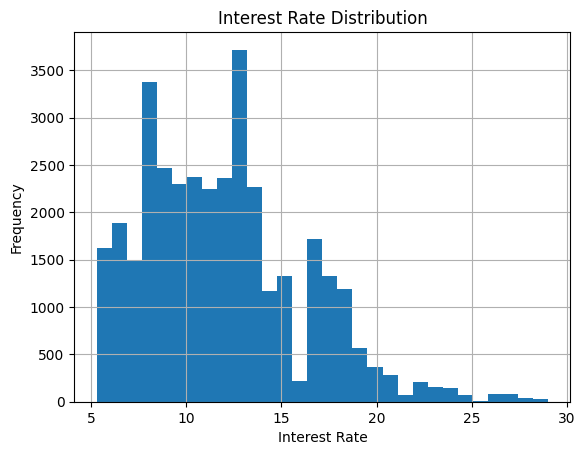


Data Types Summary:

float64    102
int32       44
object      32
int64        2
Name: count, dtype: int64


In [5]:
# STEP - Data Type Cleaning + Feature Engineering 

print("\nBefore Conversion:\n")
print(df[['term', 'emp_length', 'int_rate']].head())
if df['term'].dtype == 'object':
    df['term'] = df['term'].str.extract('(\d+)').astype(float)
if df['emp_length'].dtype == 'object':
    df['emp_length'] = df['emp_length'].str.replace(r'\D', '', regex=True)
    df['emp_length'] = df['emp_length'].replace('', 0)
    df['emp_length'] = df['emp_length'].astype(float)
if df['int_rate'].dtype == 'object':
    df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)
else:
    df['int_rate'] = df['int_rate'].astype(float)
if 'revol_util' in df.columns:
    if df['revol_util'].dtype == 'object':
        df['revol_util'] = df['revol_util'].str.replace('%', '').astype(float)
    else:
        df['revol_util'] = df['revol_util'].astype(float)
date_cols = ['issue_d']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        df[col + '_year'] = df[col].dt.year

# Drop original date
df.drop(columns=date_cols, inplace=True, errors='ignore')


# After Check

print("\nAfter Conversion:\n")
print(df[['term', 'emp_length', 'int_rate']].head())


# Graph - Interest Rate Distribution
plt.figure()
df['int_rate'].hist(bins=30)
plt.title("Interest Rate Distribution")
plt.xlabel("Interest Rate")
plt.ylabel("Frequency")
plt.show()

print("\nData Types Summary:\n")
print(df.dtypes.value_counts())

In [6]:
# STEP 4: Outlier Handling

import matplotlib.pyplot as plt
cols_to_treat = ['loan_amnt', 'annual_inc', 'int_rate']
def cap_outliers(column):
    lower = column.quantile(0.05)
    upper = column.quantile(0.95)
    
    print(f"\n{column.name}:")
    print("Lower cap:", lower)
    print("Upper cap:", upper)
    
    return column.clip(lower, upper)
for col in cols_to_treat:
    if col in df.columns:
        df[col] = cap_outliers(df[col])


loan_amnt:
Lower cap: 3000.0
Upper cap: 32000.0

annual_inc:
Lower cap: 28000.0
Upper cap: 159148.14199999906

int_rate:
Lower cap: 6.24
Upper cap: 18.99


In [8]:
# STEP - Encoding 
cat_cols = df.select_dtypes(include=['object', 'category']).columns
low_card_cols = []
high_card_cols = []

for col in cat_cols:
    if df[col].nunique() < 15:
        low_card_cols.append(col)
    else:
        high_card_cols.append(col)
# ONE-HOT ENCODING
df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

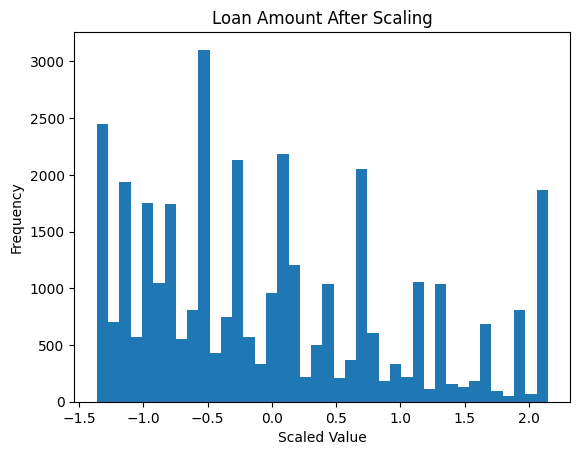

In [9]:
# STEP- FEATURE SCALING

from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Separate features & target
X = df.drop('target', axis=1)
y = df['target']

# ✅ Only numeric columns
X = X.select_dtypes(include=['int64', 'float64'])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X = pd.DataFrame(X_scaled, columns=X.columns)

# Graph
plt.figure()
plt.hist(X['loan_amnt'], bins=40)
plt.title("Loan Amount After Scaling")
plt.xlabel("Scaled Value")
plt.ylabel("Frequency")
plt.show()

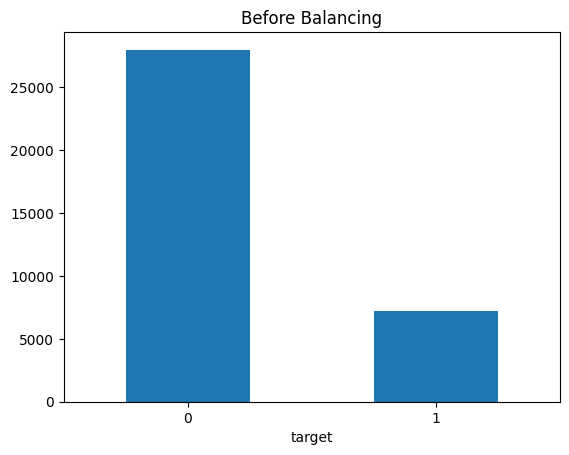


Class Distribution After:

target
1.0    24658
0.0    24658
Name: count, dtype: int64


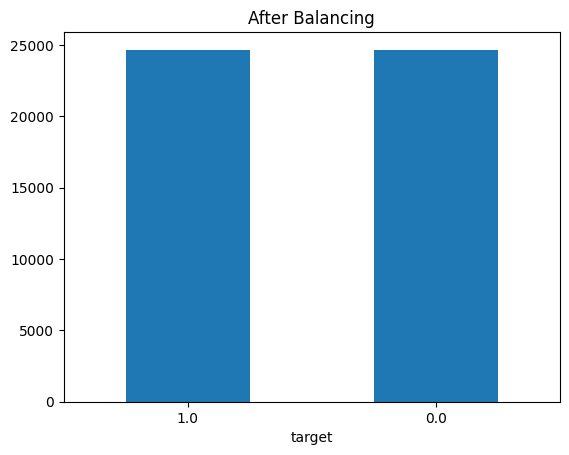

In [10]:

# STEP - HANDLE CLASS IMBALANCE

import matplotlib.pyplot as plt
from sklearn.utils import resample

y.value_counts().plot(kind='bar')
plt.title("Before Balancing")
plt.xticks(rotation=0)
plt.show()

df_bal = X.copy()
df_bal['target'] = y

majority = df_bal[df_bal['target'] == 0]
minority = df_bal[df_bal['target'] == 1]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

df_balanced = pd.concat([majority, minority_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42)

X = df_balanced.drop('target', axis=1)
y = df_balanced['target']

print("\nClass Distribution After:\n")
print(y.value_counts())

y.value_counts().plot(kind='bar')
plt.title("After Balancing")
plt.xticks(rotation=0)
plt.show()

C:\Users\shrut\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\shrut\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\shrut\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\shrut\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", l

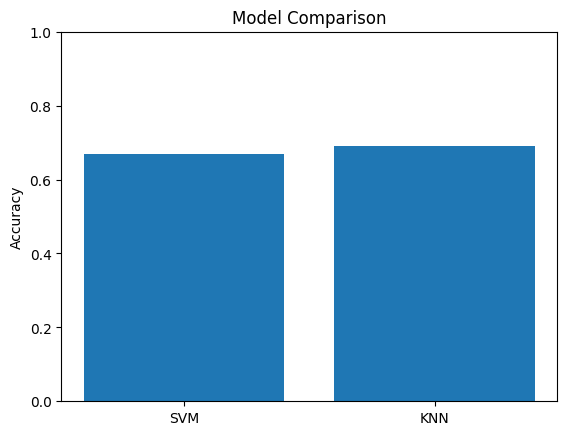

SVM Accuracy: 0.6698094079480941
KNN Accuracy: 0.690389294403893


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Fill NaNs
X = X.fillna(0)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------- SVM --------
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

# -------- KNN --------
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

# -------- GRAPH --------
models = ['SVM', 'KNN']
scores = [svm_acc, knn_acc]

plt.figure()
plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

# Print accuracy
print("SVM Accuracy:", svm_acc)
print("KNN Accuracy:", knn_acc)

In [ ]:
# -------- SAMPLE DATA --------
sample_df = X.copy()
sample_df['target'] = y

sample_df = sample_df.sample(n=5000, random_state=42)

X = sample_df.drop('target', axis=1)
y = sample_df['target']


# -------- TRAIN TEST SPLIT --------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# -------- FAST SVM --------
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight='balanced', max_iter=2000)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))


# -------- KNN --------
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

In [ ]:

# STEP 9: PCA

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X)

plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Variance Explained")
plt.show()


# Applying PCA (95% variance)
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X)

print("\nOriginal Features:", X.shape[1])
print("Reduced Features:", X_pca.shape[1])


# -------- 3. TRAIN TEST SPLIT --------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# -------- 4. TRAIN SVM AGAIN --------
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC(kernel='rbf', class_weight='balanced')

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("\nSVM Accuracy After PCA:", accuracy_score(y_test, y_pred))

In [ ]:
# -------- IMPORTS --------
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# -------- FEATURES & TARGET --------
X = df.drop('target', axis=1)
y = df['target']

# Keep only numeric columns
X = X.select_dtypes(include=['int64', 'float64'])

# Fill missing values
X = X.fillna(0)

# -------- SCALING --------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------- TRAIN TEST SPLIT --------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------- PCA --------
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original shape:", X_train.shape)
print("Reduced shape:", X_train_pca.shape)

# -------- MODELS --------

# SVM (3 kernels)
svm_linear = SVC(kernel='linear', probability=True)
svm_poly = SVC(kernel='poly', degree=3, probability=True)
svm_rbf = SVC(kernel='rbf', probability=True)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)

# Train
svm_linear.fit(X_train_pca, y_train)
svm_poly.fit(X_train_pca, y_train)
svm_rbf.fit(X_train_pca, y_train)
knn.fit(X_train_pca, y_train)

print("Models trained ✅")

# -------- EVALUATION FUNCTION --------
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))

    return accuracy_score(y_test, y_pred)

# -------- EVALUATE --------
acc1 = evaluate(svm_linear, X_test_pca, y_test, "SVM Linear")
acc2 = evaluate(svm_poly, X_test_pca, y_test, "SVM Polynomial")
acc3 = evaluate(svm_rbf, X_test_pca, y_test, "SVM RBF")
acc4 = evaluate(knn, X_test_pca, y_test, "KNN")

# -------- GRAPH --------
models = ['SVM Linear', 'SVM Poly', 'SVM RBF', 'KNN']
scores = [acc1, acc2, acc3, acc4]

plt.figure()
plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.ylim(0,1)
plt.show()

Original shape: (28156, 103)
Reduced shape: (28156, 59)
